# Базовые методы anomaly detection и их метрики

### Методы:
1. Mahalanobis Distance (с LedoitWolf). Модель учит расспределение и далее считает расстояние до тестовых эмбеддингов.
2. Robust Covariance + PCA + MinCovDet. Вариант предыдущего.
3. Isolation Forest. Количество разрезов для изоляции.
4. kNN Distance. Аномалии далеко от своих ближайших соседей.
5. Local Outlier Factor (LOF). Сравнивает плотность точки относительно плотности её соседей. Если точка в регионе с резко меньшей плотностью, чем у соседей, то она аномалбная.
6. Autoencoder. Учится хорошо восстанавливать нормальные данные.

### Энкодеры
От простого до более мощного:
1. all-MiniLM-L6-v2
2. all-mpnet-base-v2
3. e5-base

**Эмбеддинги - текстов целиком**

### Данные
- TRAIN: Живые эссе с Ivy Panda, 90805 штук.
- TEST: Живые эссе с Ivy Panda + сгенерированные (Mistral 7B, Llama 3 13B, ChatGPT, DeepSeek). Пропорции 50/50. Суммарно 74976 штук.

In [1]:
ENCODERS = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "intfloat/e5-base",
]

KNN_N_NEIGHBORS = 5
LOF_N_NEIGHBORS = 20
ENCODE_BATCH_SIZE = 64
AE_EPOCH_N = 30

device = "mps"

In [2]:
import numpy as np
from sklearn.covariance import LedoitWolf, MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc, precision_recall_curve, silhouette_score, davies_bouldin_score
import torch
import torch.nn as nn
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances
import random

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [5]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]
df_ai = pd.concat([pd.read_csv(f) for f in filenames], ignore_index=True).assign(label=1)[["text", "label"]]

df_human = pd.read_csv("../datasets/ivy_panda_essays.csv").assign(label=0)[["text", "label"]].reset_index(drop=True)
df_train, df_human_test = train_test_split(df_human, test_size=len(df_ai), random_state=SEED)

df_all = pd.concat([df_ai, df_human_test], ignore_index=True).sample(frac=1, random_state=SEED)

In [6]:
print(f"Загружено {len(df_train)} записей Ivy Panda (живые, train)")
print(f"Загружено {len(df_all)} записей (синтетика + живые, test)")

Загружено 90805 записей Ivy Panda (живые, train)
Загружено 74976 записей (синтетика + живые, test)


In [7]:
class AE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, dim),
        )
    def forward(self, x):
        return self.dec(self.enc(x))

In [8]:
def plot_score_distribution(scores, y, title):
    plt.figure(figsize=(8,4))
    sns.kdeplot(scores[y==0], label="normal", fill=True, alpha=0.4)
    sns.kdeplot(scores[y==1], label="anomaly", fill=True, alpha=0.4)
    plt.title(title)
    plt.xlabel("score")
    plt.ylabel("density")
    plt.legend()
    plt.show()

def plot_roc_pr(scores_dict, y):
    plt.figure(figsize=(8,4))
    for name, s in scores_dict.items():
        fpr, tpr, _ = roc_curve(y, s)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("ROC Curves")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    for name, s in scores_dict.items():
        pr, rc, _ = precision_recall_curve(y, s)
        ap = average_precision_score(y, s)
        plt.plot(rc, pr, label=f"{name} (AP={ap:.3f})")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title("Precision-Recall Curves")
    plt.legend()
    plt.show()

def plot_tsne(X, y, title):
    idx = np.random.choice(len(X), size=min(2000, len(X)), replace=False)
    Xsub = X[idx]
    ysub = y[idx]
    
    Xp = PCA(30).fit_transform(Xsub)
    Xt = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(Xp)
    
    plt.figure(figsize=(8,4))
    plt.scatter(Xt[ysub==0,0], Xt[ysub==0,1], s=10, alpha=0.5, label='normal')
    plt.scatter(Xt[ysub==1,0], Xt[ysub==1,1], s=10, alpha=0.7, label='anomaly')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_correlation(scores_dict):
    mat = np.vstack(list(scores_dict.values()))
    corr = np.corrcoef(mat)
    
    plt.figure(figsize=(8,4))
    sns.heatmap(corr, annot=True, xticklabels=scores_dict.keys(), yticklabels=scores_dict.keys())
    plt.title("Score Correlation Heatmap")
    plt.show()

def plot_precision_at_k(scores, y, title, ks=[10,20,50,100,200]):
    order = np.argsort(scores)[::-1]
    y_sorted = y[order]
    
    prec = []
    for k in ks:
        if k > len(y_sorted):
            prec.append(np.nan)
        else:
            prec.append(np.mean(y_sorted[:k]))
    
    plt.figure(figsize=(8,4))
    plt.plot(ks, prec, marker='o')
    plt.xlabel("K (top anomalies)")
    plt.ylabel("Precision@K")
    plt.title(title)
    plt.grid()
    plt.show()

def plot_pca_kde(X, y, title):
    Z = PCA(n_components=2).fit_transform(X)
    df = pd.DataFrame({"PC1": Z[:,0], "PC2": Z[:,1], "label": y})
    
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df[df.label==0], x="PC1", y="PC2", fill=True, cmap="Blues", alpha=0.6, levels=30)
    sns.kdeplot(data=df[df.label==1], x="PC1", y="PC2", fill=True, cmap="Reds", alpha=0.6, levels=30)
    plt.title(title)
    plt.show()

def plot_cosine_dists(X, y, title):
    X_h = X[y==0]
    X_ai = X[y==1]

    D_hh = pairwise_distances(X_h[:2000], X_h[:2000], metric="cosine").flatten()
    D_aa = pairwise_distances(X_ai[:2000], X_ai[:2000], metric="cosine").flatten()
    D_ha = pairwise_distances(X_h[:2000], X_ai[:2000], metric="cosine").flatten()

    plt.figure(figsize=(8,4))
    sns.kdeplot(D_hh, label="H-H", alpha=0.7)
    sns.kdeplot(D_aa, label="A-A", alpha=0.7)
    sns.kdeplot(D_ha, label="H-A", alpha=0.7)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_centroid_heatmap(X, y, title):
    c0 = X[y==0].mean(axis=0)
    c1 = X[y==1].mean(axis=0)
    
    D0 = X[y==0] @ c0 / (np.linalg.norm(X[y==0], axis=1)*np.linalg.norm(c0))
    D1 = X[y==1] @ c1 / (np.linalg.norm(X[y==1], axis=1)*np.linalg.norm(c1))

    plt.figure(figsize=(8,4))
    sns.kdeplot(D0, label="Human → Human centroid")
    sns.kdeplot(D1, label="AI → AI centroid")
    plt.title(title)
    plt.legend()
    plt.show()

In [9]:
def eval_scores(name, scores, y):
    auc = roc_auc_score(y, scores)
    ap = average_precision_score(y, scores)
    print(f"{name:20s} | ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")

def print_cluster_scores(X, y, title):
    print(title)
    print("Silhouette:", silhouette_score(X, y))
    print("Davies-Bouldin:", davies_bouldin_score(X, y))

В этом эксперименте самое простые эмбеддинги - текстов целиком:

In [10]:
def get_embeddings(model, data):
    return model.encode(data, batch_size=ENCODE_BATCH_SIZE, show_progress_bar=True, device=device)

Batches:   0%|          | 0/1419 [00:00<?, ?it/s]

Batches:   0%|          | 0/1172 [00:00<?, ?it/s]

X_train: (90805, 384)
X_test: (74976, 384)
y_test: (74976,) | аномалий: 37488


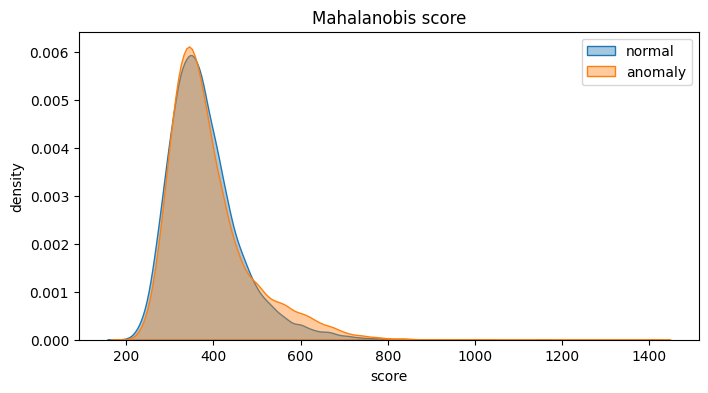

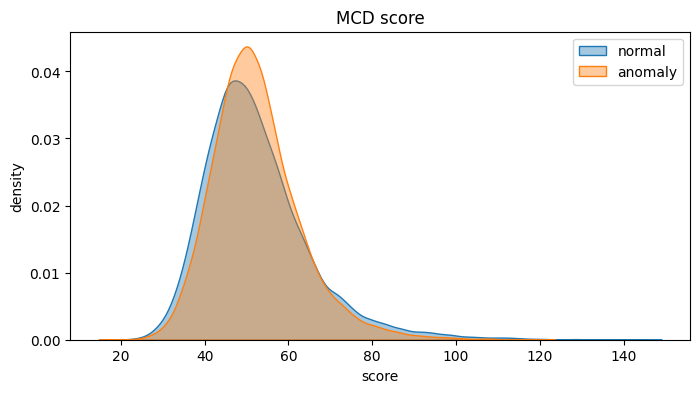

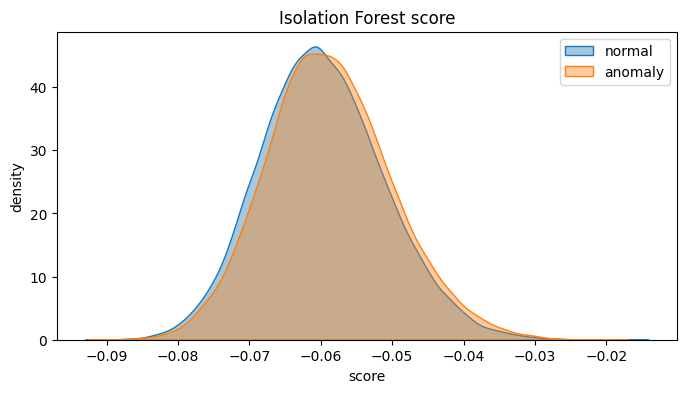

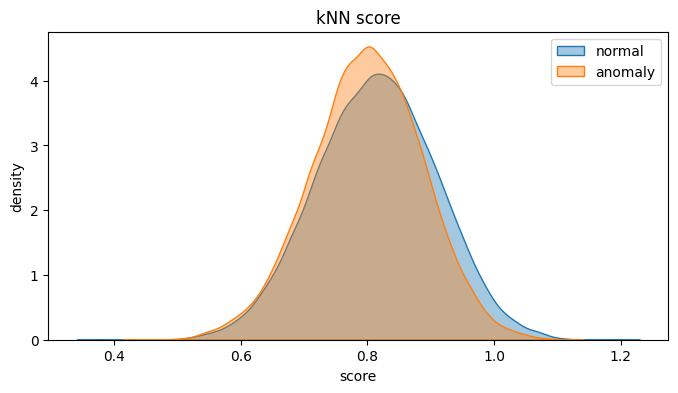

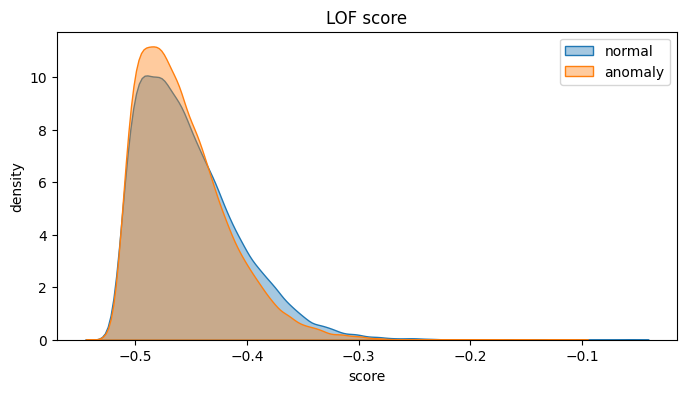

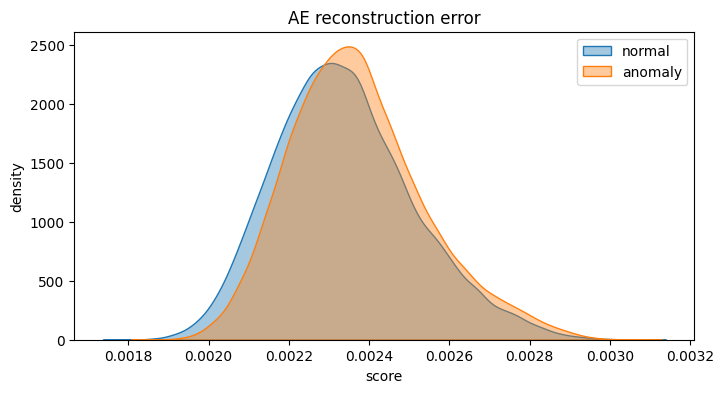

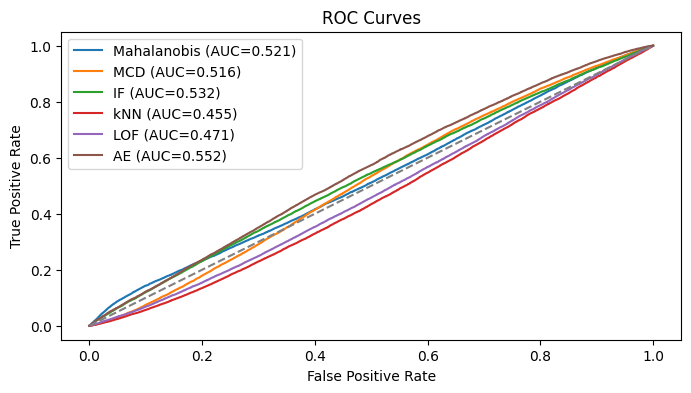

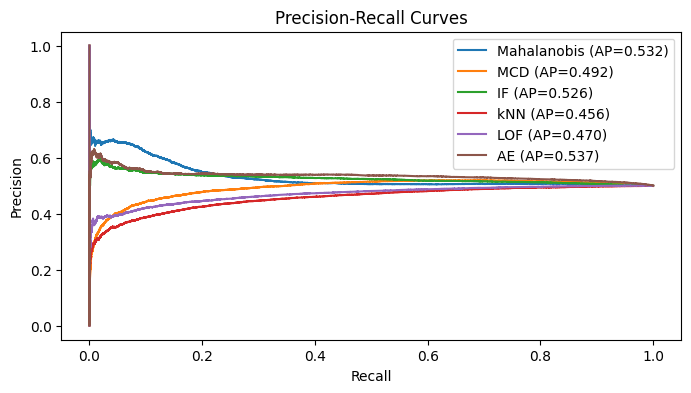

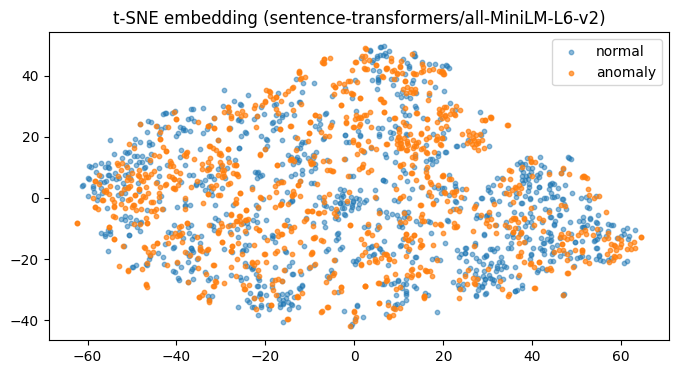

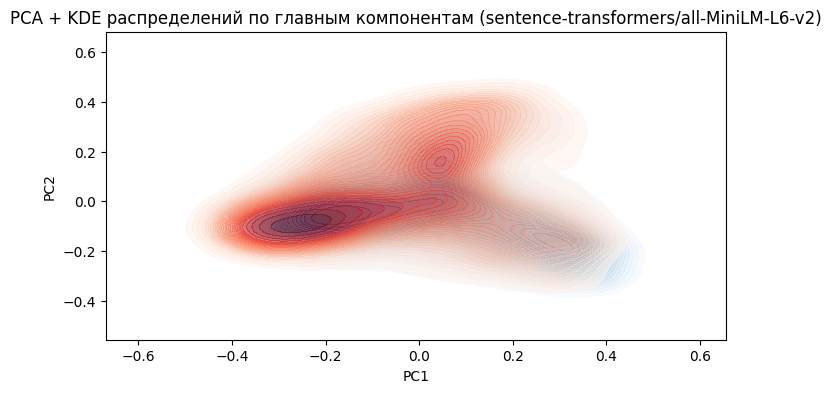

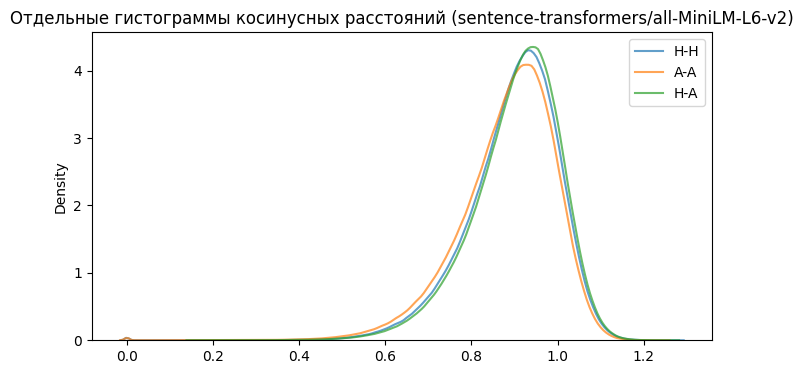

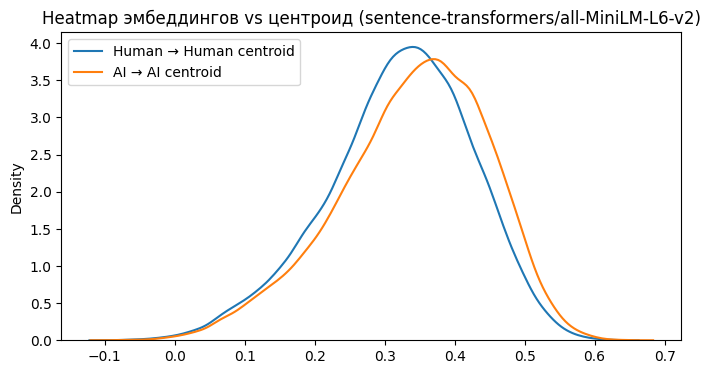

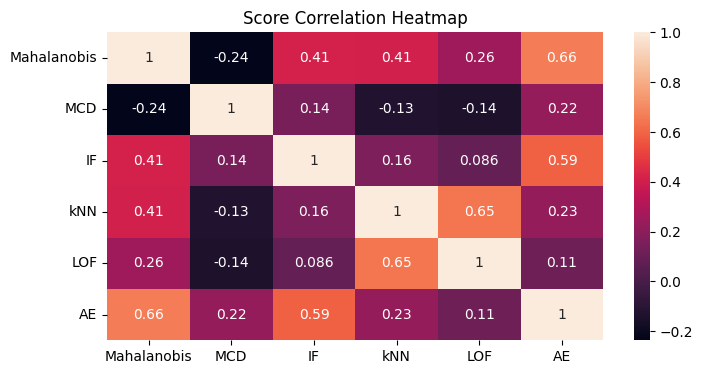

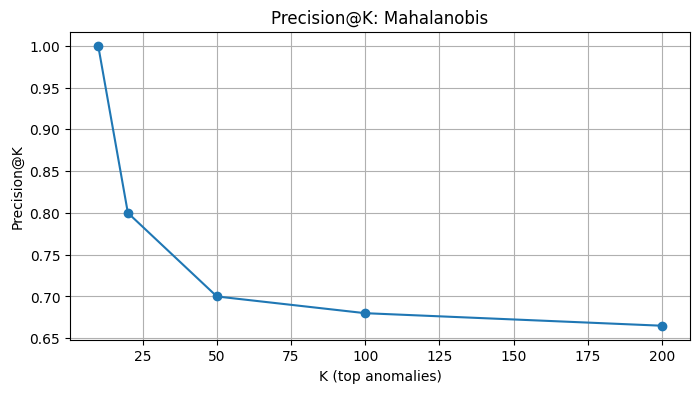

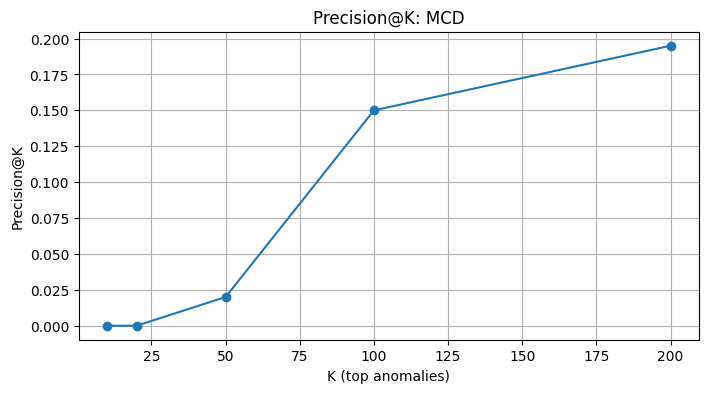

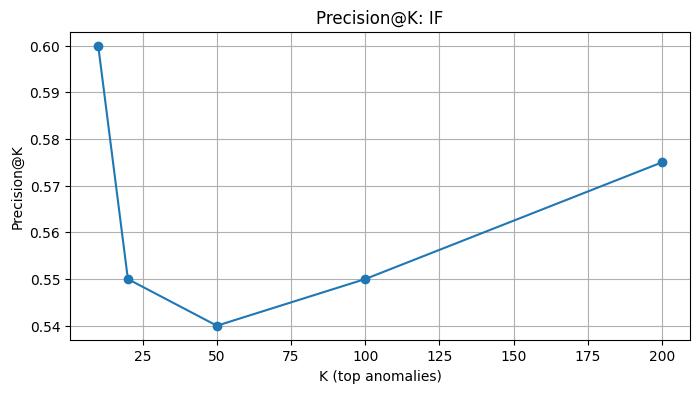

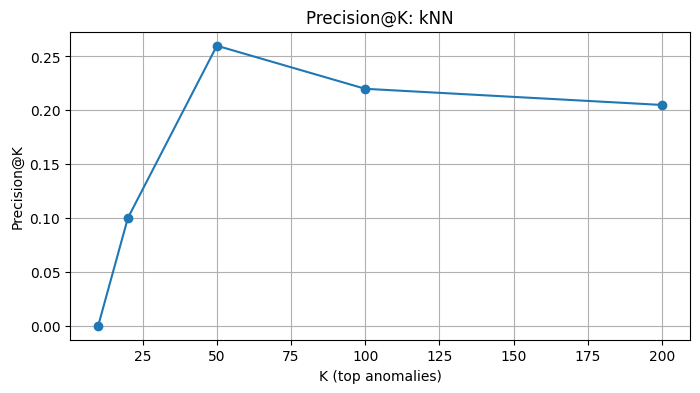

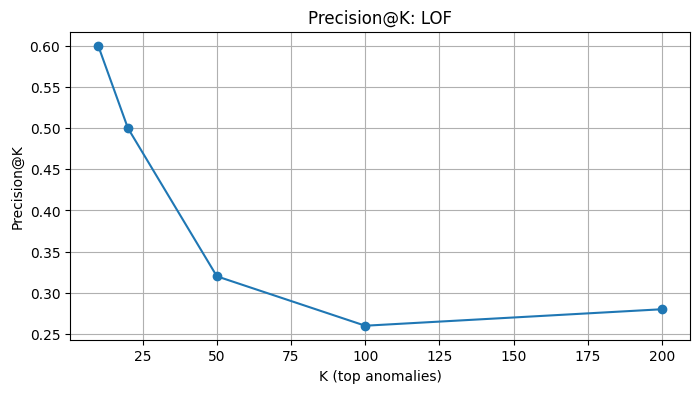

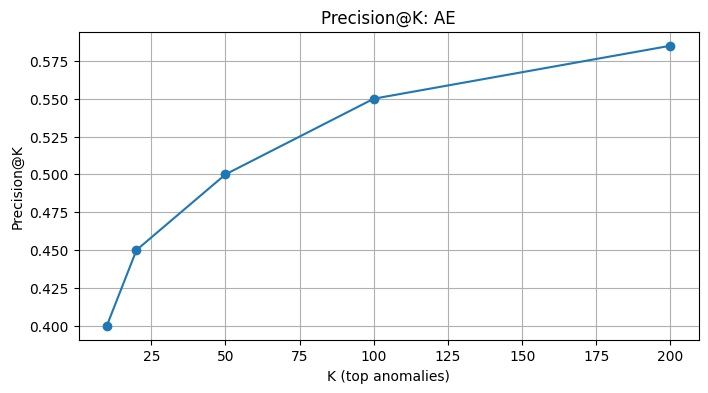

Кластерные метрики (sentence-transformers/all-MiniLM-L6-v2)
Silhouette: 0.007598419673740864
Davies-Bouldin: 11.5705571453716


Batches:   0%|          | 0/1419 [00:00<?, ?it/s]

Batches:   0%|          | 0/1172 [00:00<?, ?it/s]

X_train: (90805, 768)
X_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


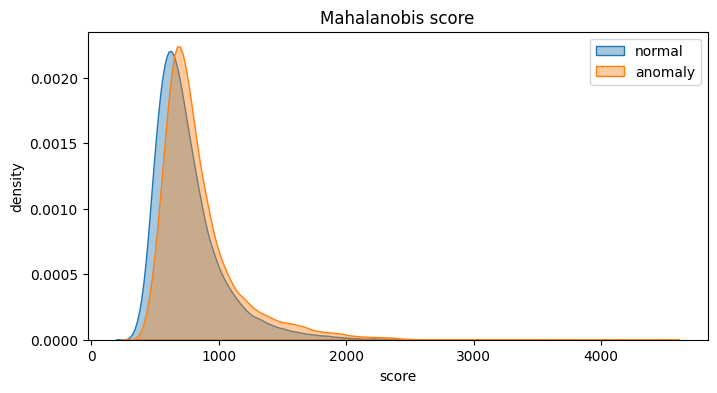

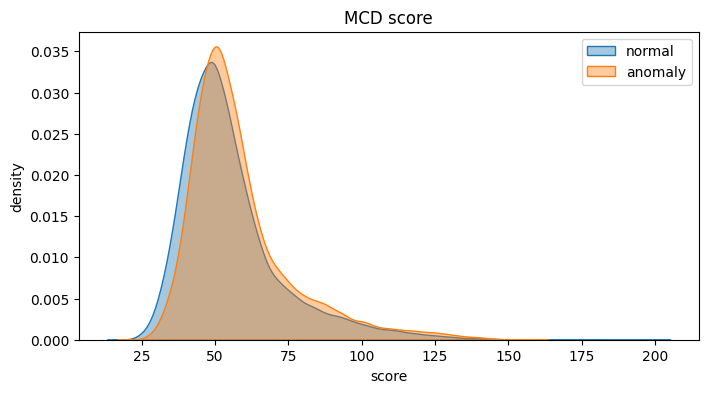

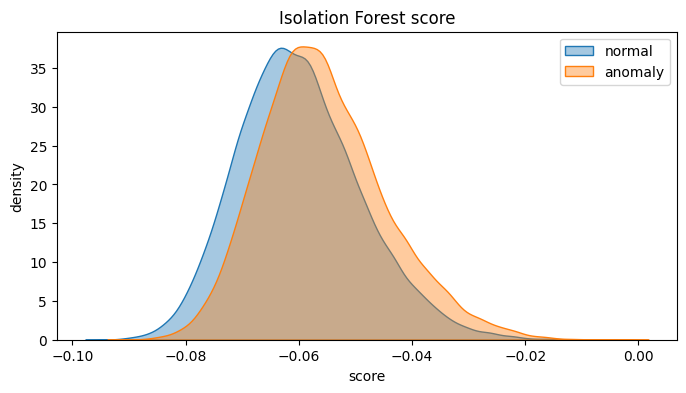

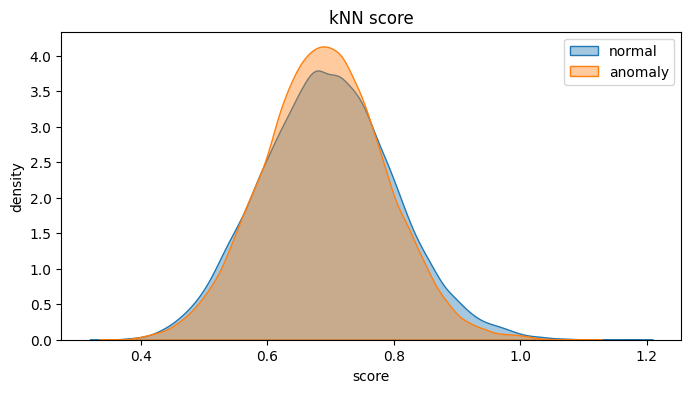

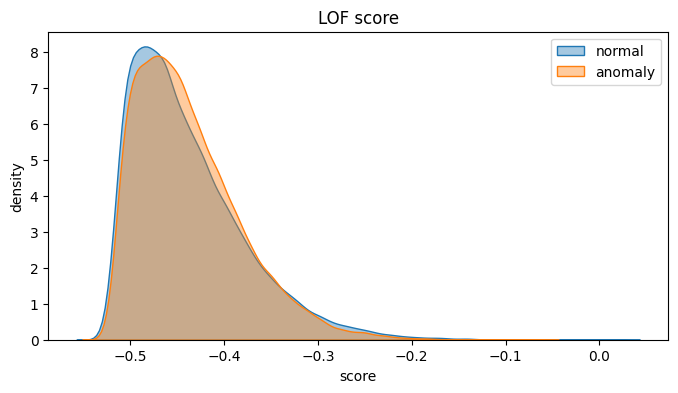

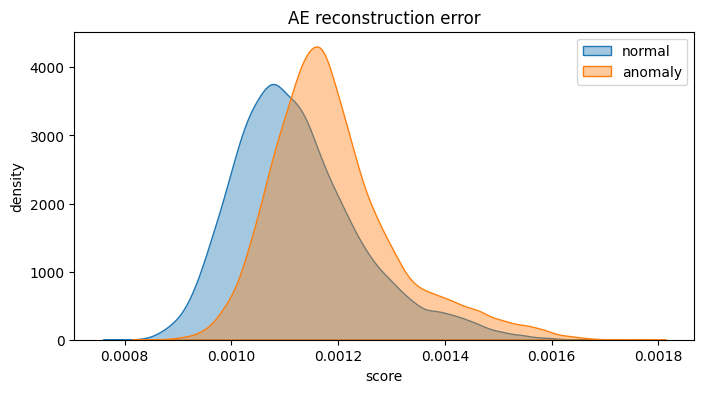

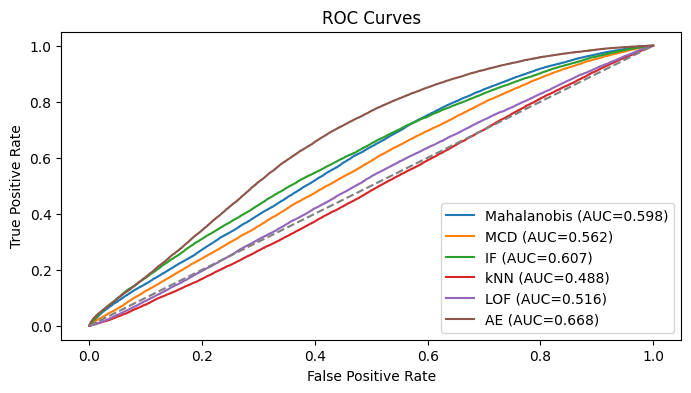

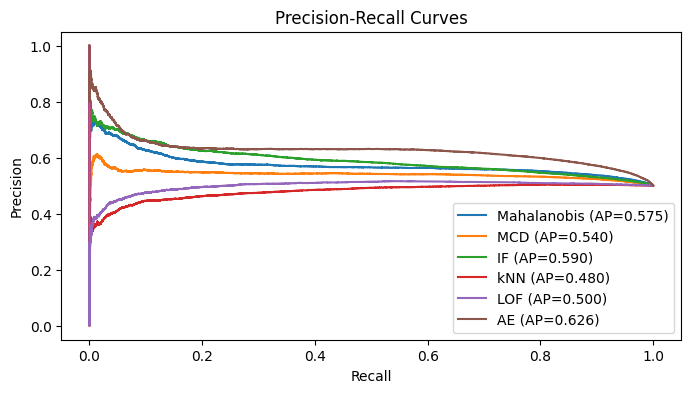

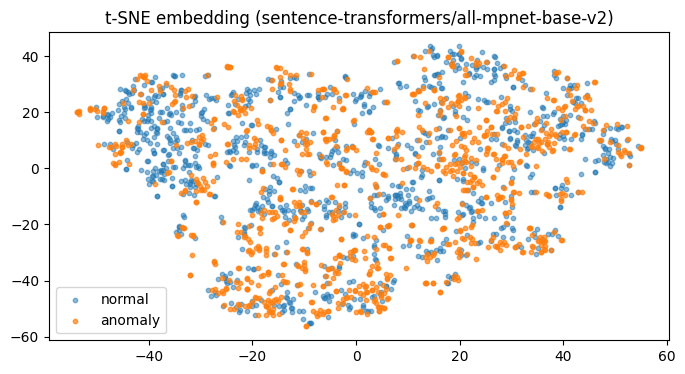

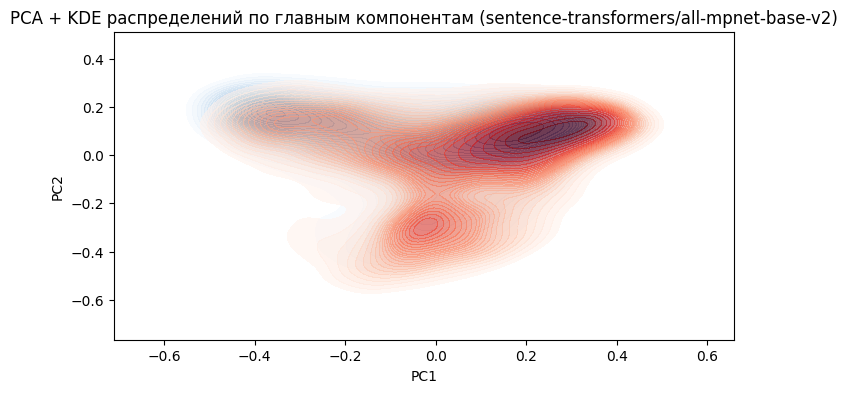

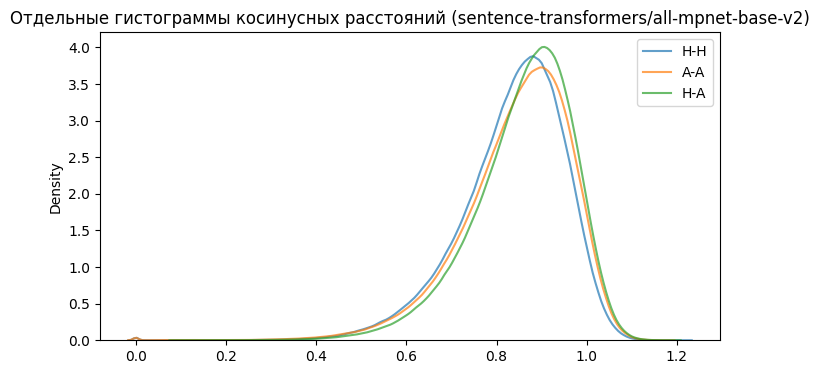

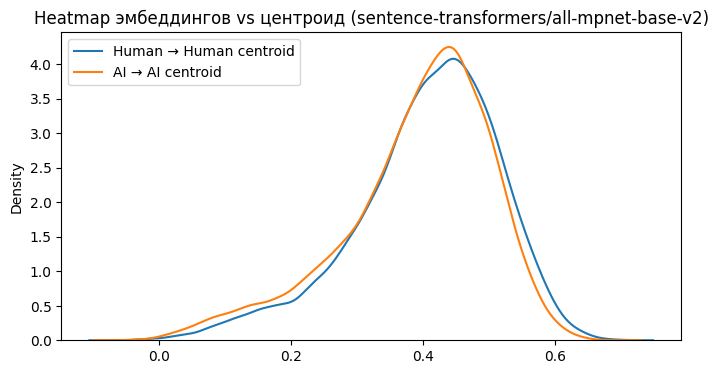

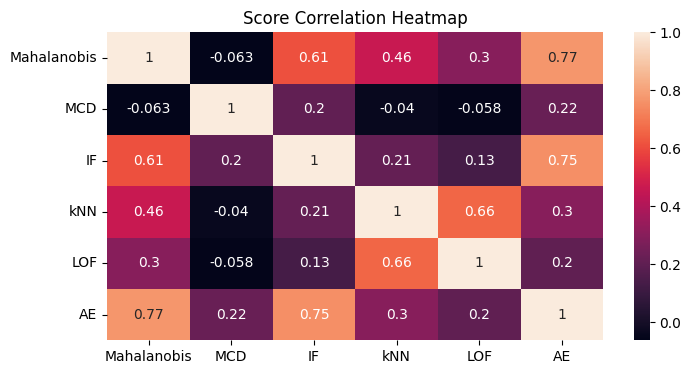

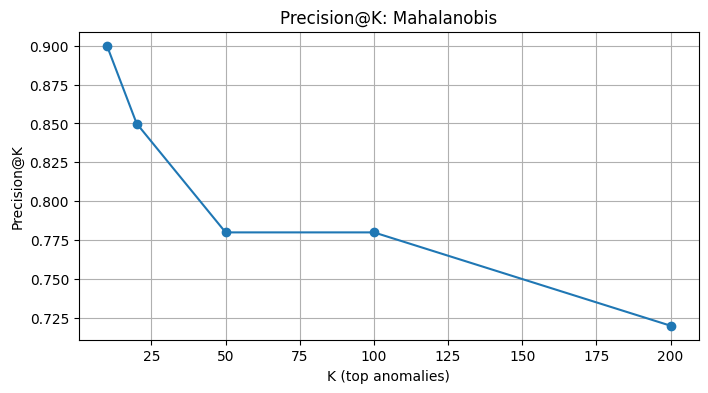

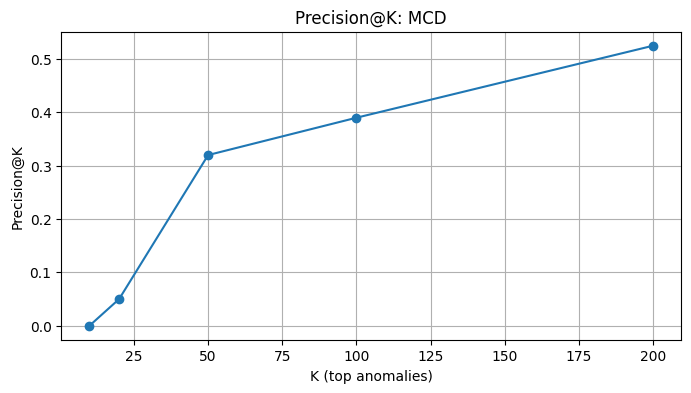

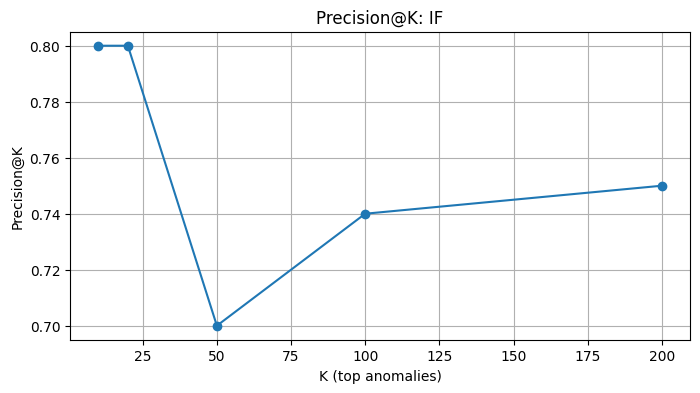

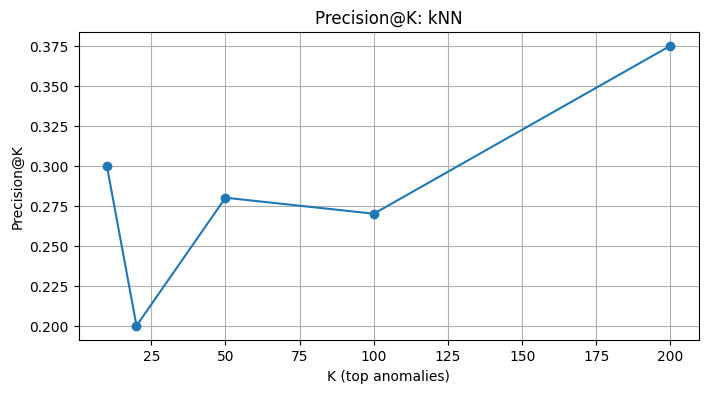

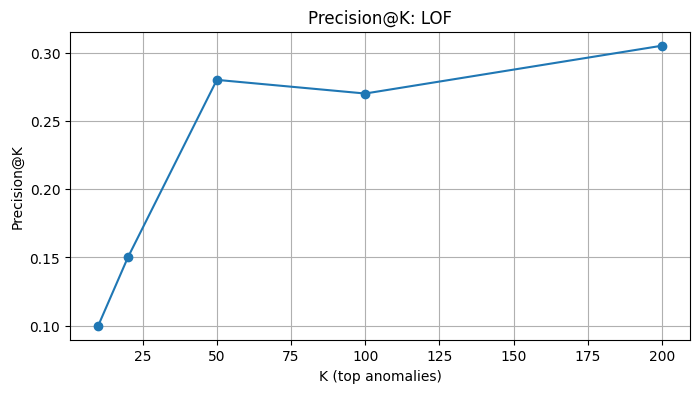

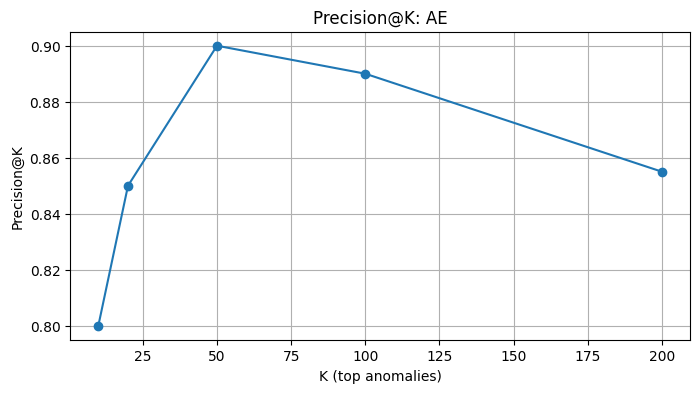

Кластерные метрики (sentence-transformers/all-mpnet-base-v2)
Silhouette: 0.010907197371125221
Davies-Bouldin: 9.633146279530804


Batches:   0%|          | 0/1419 [00:00<?, ?it/s]

Batches:   0%|          | 0/1172 [00:00<?, ?it/s]

X_train: (90805, 768)
X_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


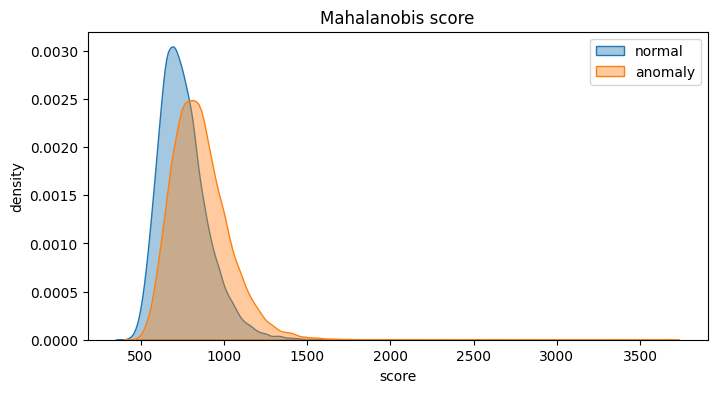

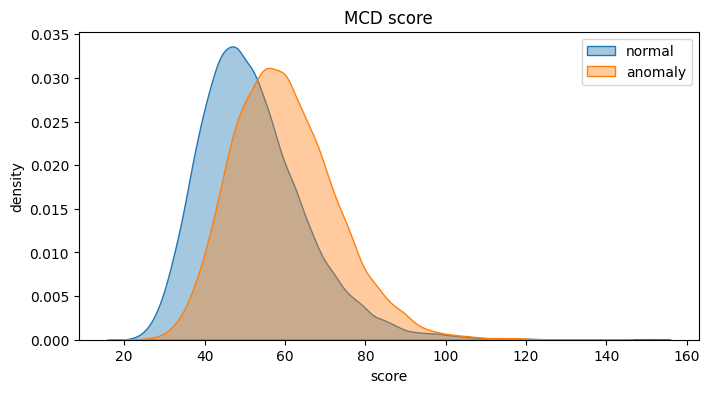

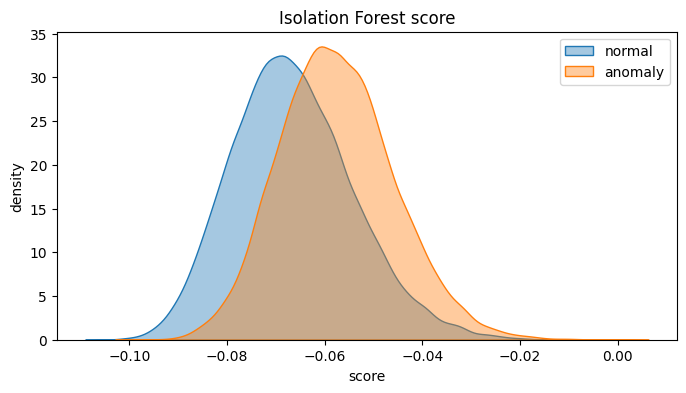

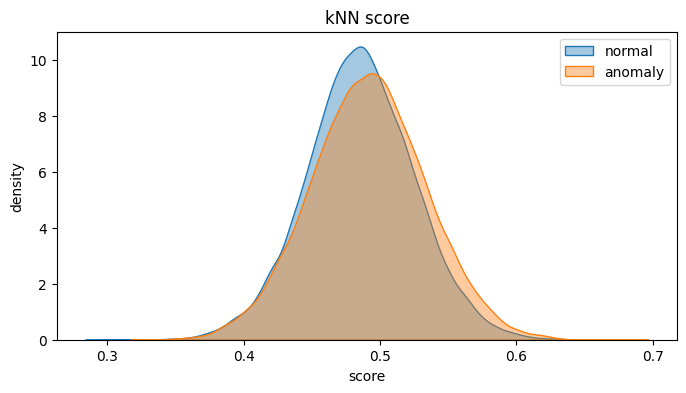

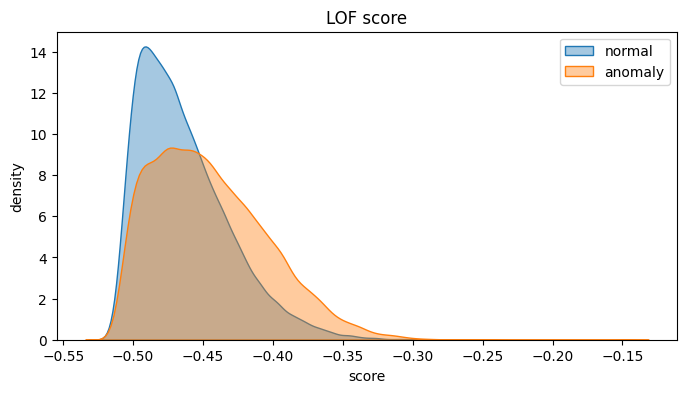

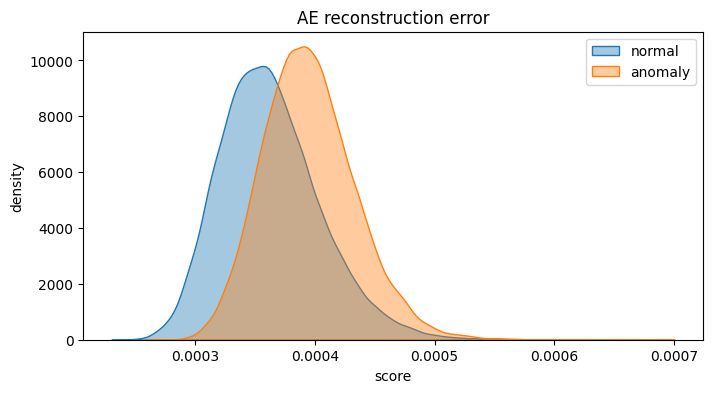

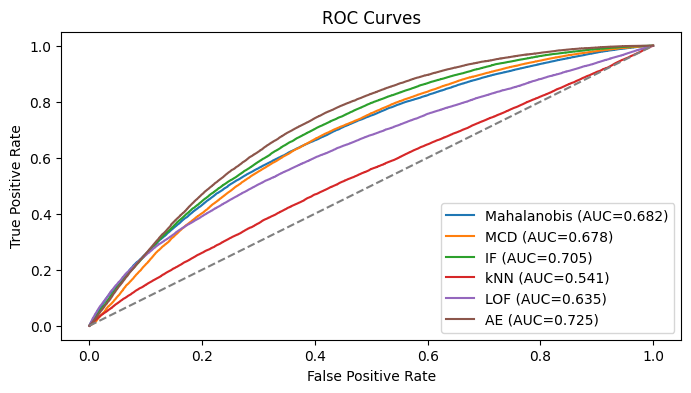

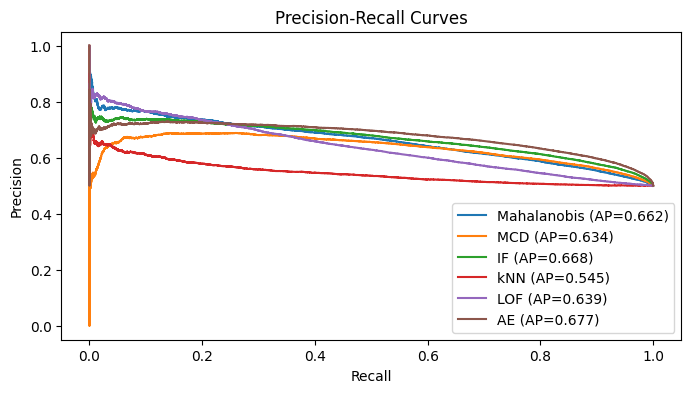

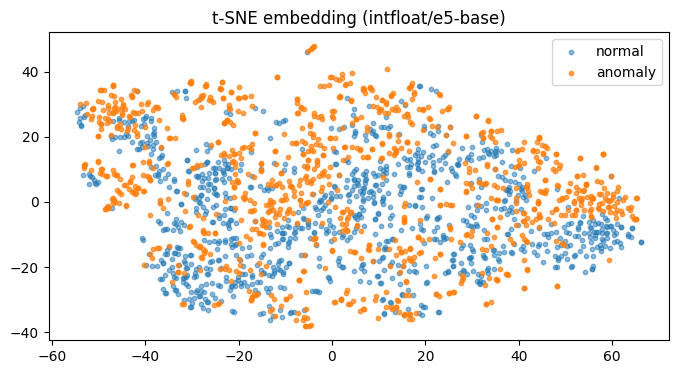

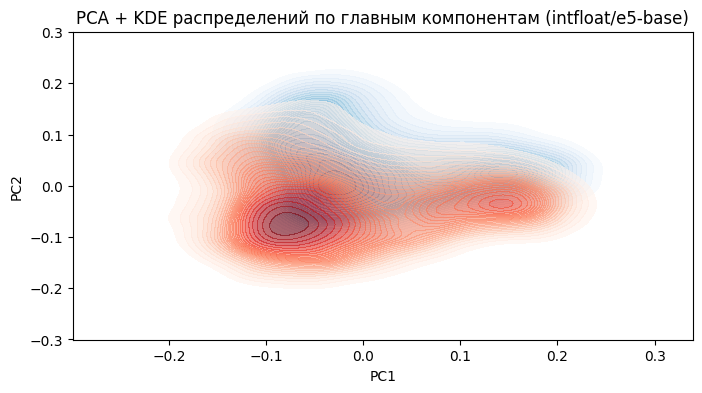

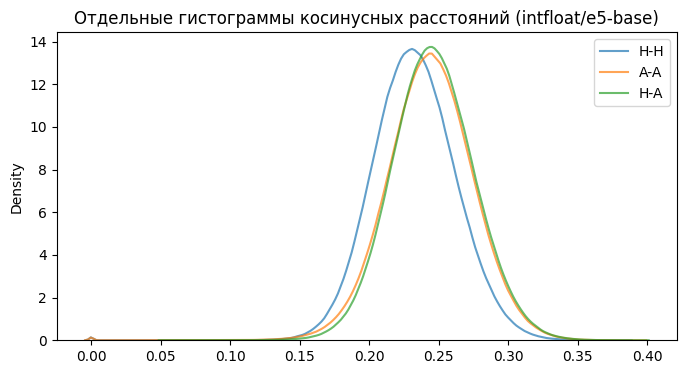

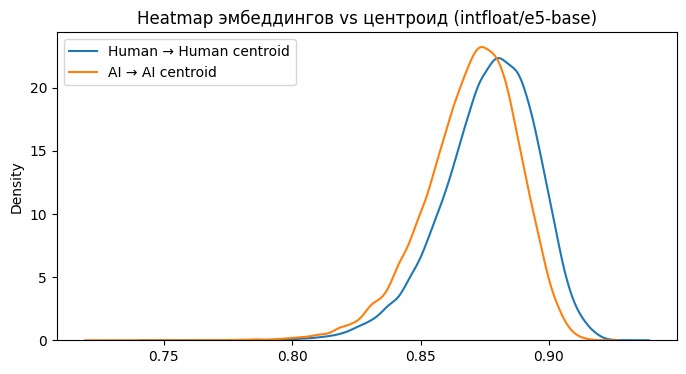

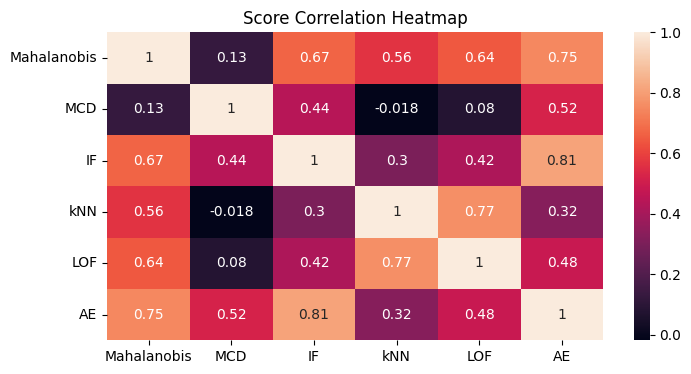

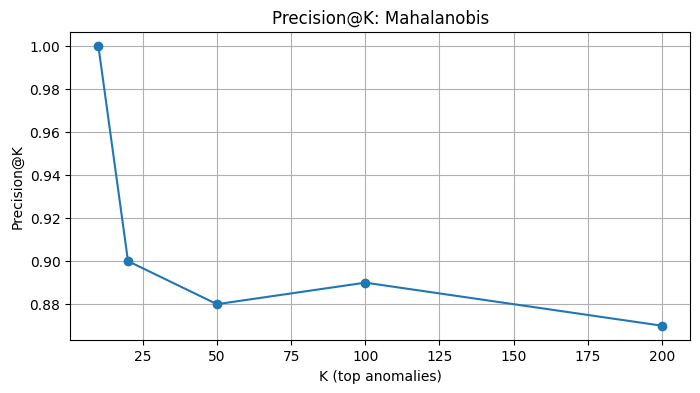

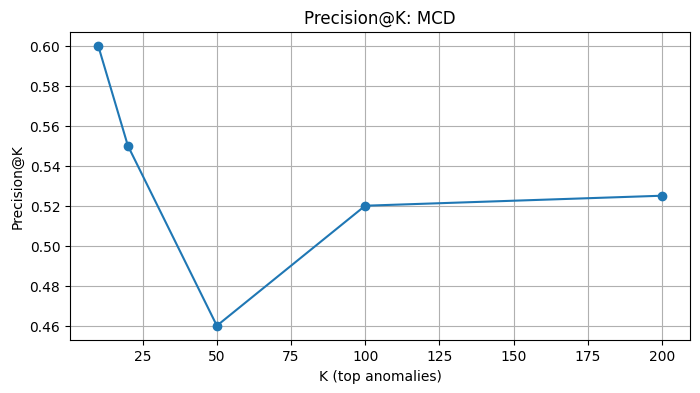

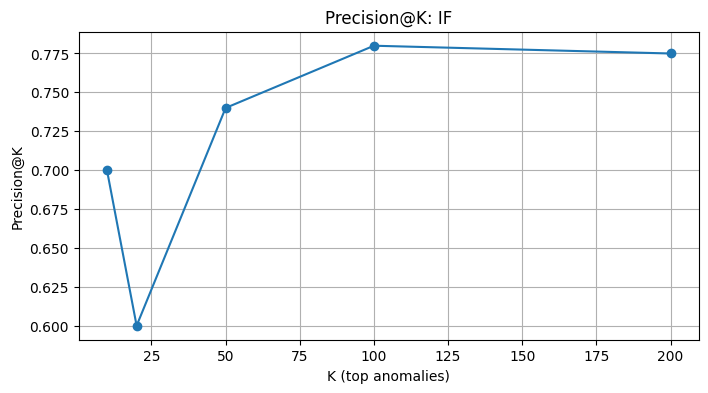

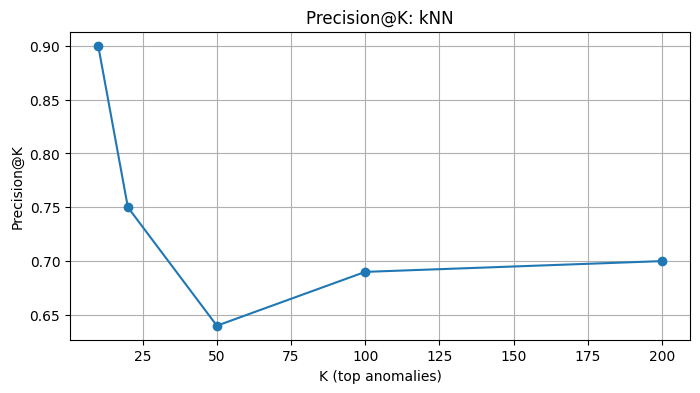

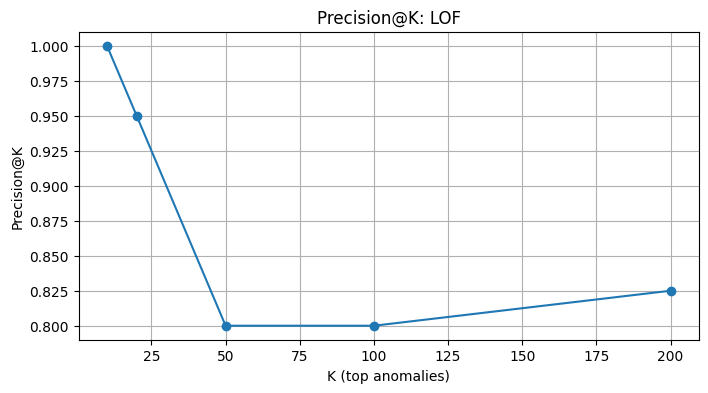

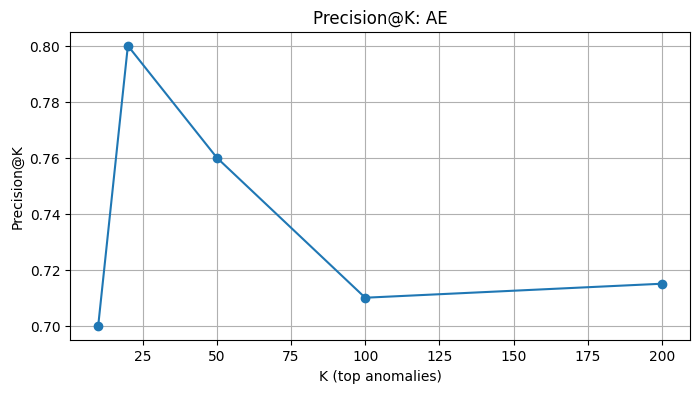

Кластерные метрики (intfloat/e5-base)
Silhouette: 0.01627918891608715
Davies-Bouldin: 7.797337231334552


In [11]:
results = dict()

for model_name in ENCODERS:
    model = SentenceTransformer(model_name)

    X_train = get_embeddings(model, df_train['text'].tolist())
    
    X_test = get_embeddings(model, df_all['text'].tolist())
    y_test = df_all['label'].values.astype(int)

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape, "| аномалий:", sum(y_test))

    # 1. Mahalanobis Distance
    lw = LedoitWolf().fit(X_train)
    mahal_scores = lw.mahalanobis(X_test)

    # 2. Robust Covariance (с Minimum Covariance Determinant)
    pca = PCA(n_components=50, whiten=True, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    mcd = MinCovDet(support_fraction=0.75, random_state=SEED)
    mcd.fit(X_train_pca)
    mcd_scores = mcd.mahalanobis(X_test_pca)
    
    # 3. Isolation Forest
    iso = IsolationForest(contamination='auto', n_estimators=200, random_state=SEED)
    iso.fit(X_train)
    iso_scores = -iso.decision_function(X_test)
    
    # 4. kNN Distance
    nn_model = NearestNeighbors(n_neighbors=KNN_N_NEIGHBORS)
    nn_model.fit(X_train)
    distances, _ = nn_model.kneighbors(X_test)
    knn_scores = distances.mean(axis=1)
    
    # 5. Local Outlier Factor (LOF)
    lof = LocalOutlierFactor(n_neighbors=LOF_N_NEIGHBORS, novelty=True)
    lof.fit(X_train)
    lof_scores = -lof.decision_function(X_test)
    
    # 6. Autoencoder (MLP)
    d = X_train.shape[1]

    ae = AE(d).to(device)
    opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
    for epoch in range(AE_EPOCH_N):
        idx = torch.randperm(Xtr.shape[0])
        batch = Xtr[idx][:256]
        out = ae(batch)
        loss = loss_fn(out, batch)
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    Xe = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        recon = ae(Xe).cpu().numpy()
    ae_scores = np.mean((X_test - recon) ** 2, axis=1)

    plot_score_distribution(mahal_scores, y_test, "Mahalanobis score")
    plot_score_distribution(mcd_scores, y_test, "MCD score")
    plot_score_distribution(iso_scores, y_test, "Isolation Forest score")
    plot_score_distribution(knn_scores, y_test, "kNN score")
    plot_score_distribution(lof_scores, y_test, "LOF score")
    plot_score_distribution(ae_scores, y_test, "AE reconstruction error")

    scores = {
        "Mahalanobis": mahal_scores,
        "MCD": mcd_scores,
        "IF": iso_scores,
        "kNN": knn_scores,
        "LOF": lof_scores,
        "AE": ae_scores
    }
    plot_roc_pr(scores, y_test)
    plot_tsne(X_test, y_test, f"t-SNE embedding ({model_name})")
    plot_pca_kde(X_test, y_test, f"PCA + KDE распределений по главным компонентам ({model_name})")
    plot_cosine_dists(X_test, y_test, f"Отдельные гистограммы косинусных расстояний ({model_name})")
    plot_centroid_heatmap(X_test, y_test, f"Heatmap эмбеддингов vs центроид ({model_name})")
    plot_correlation(scores)

    for name, s in scores.items():
        plot_precision_at_k(s, y_test, f"Precision@K: {name}")

    print_cluster_scores(X_test, y_test, f"Кластерные метрики ({model_name})")

    results[model_name] = {
        "Mahalanobis": [mahal_scores, y_test],
        "MCD": [mcd_scores, y_test],
        "IsolationForest": [iso_scores, y_test],
        "kNN distance": [knn_scores, y_test],
        "LOF": [lof_scores, y_test],
        "Autoencoder": [ae_scores, y_test],
    }

## Итого

In [12]:
for model_name, model_result in results.items():
    print(f"\n=== Результат ({model_name}) ===")
    
    for method_name, scores in model_result.items():
        eval_scores(method_name, scores[0], scores[1])

    print("\n")


=== Результат (sentence-transformers/all-MiniLM-L6-v2) ===
Mahalanobis          | ROC-AUC: 0.5212 | PR-AUC: 0.5320
MCD                  | ROC-AUC: 0.5161 | PR-AUC: 0.4918
IsolationForest      | ROC-AUC: 0.5320 | PR-AUC: 0.5264
kNN distance         | ROC-AUC: 0.4548 | PR-AUC: 0.4560
LOF                  | ROC-AUC: 0.4708 | PR-AUC: 0.4696
Autoencoder          | ROC-AUC: 0.5520 | PR-AUC: 0.5367



=== Результат (sentence-transformers/all-mpnet-base-v2) ===
Mahalanobis          | ROC-AUC: 0.5977 | PR-AUC: 0.5747
MCD                  | ROC-AUC: 0.5625 | PR-AUC: 0.5403
IsolationForest      | ROC-AUC: 0.6071 | PR-AUC: 0.5902
kNN distance         | ROC-AUC: 0.4877 | PR-AUC: 0.4796
LOF                  | ROC-AUC: 0.5161 | PR-AUC: 0.4996
Autoencoder          | ROC-AUC: 0.6683 | PR-AUC: 0.6262



=== Результат (intfloat/e5-base) ===
Mahalanobis          | ROC-AUC: 0.6818 | PR-AUC: 0.6619
MCD                  | ROC-AUC: 0.6778 | PR-AUC: 0.6343
IsolationForest      | ROC-AUC: 0.7048 | PR-AUC: 0.66

```
=== Результат (sentence-transformers/all-MiniLM-L6-v2) ===
Mahalanobis          | ROC-AUC: 0.5212 | PR-AUC: 0.5320
MCD                  | ROC-AUC: 0.5161 | PR-AUC: 0.4918
IsolationForest      | ROC-AUC: 0.5320 | PR-AUC: 0.5264
kNN distance         | ROC-AUC: 0.4548 | PR-AUC: 0.4560
LOF                  | ROC-AUC: 0.4708 | PR-AUC: 0.4696
Autoencoder          | ROC-AUC: 0.5520 | PR-AUC: 0.5367



=== Результат (sentence-transformers/all-mpnet-base-v2) ===
Mahalanobis          | ROC-AUC: 0.5977 | PR-AUC: 0.5747
MCD                  | ROC-AUC: 0.5625 | PR-AUC: 0.5403
IsolationForest      | ROC-AUC: 0.6071 | PR-AUC: 0.5902
kNN distance         | ROC-AUC: 0.4877 | PR-AUC: 0.4796
LOF                  | ROC-AUC: 0.5161 | PR-AUC: 0.4996
Autoencoder          | ROC-AUC: 0.6683 | PR-AUC: 0.6262



=== Результат (intfloat/e5-base) ===
Mahalanobis          | ROC-AUC: 0.6818 | PR-AUC: 0.6619
MCD                  | ROC-AUC: 0.6778 | PR-AUC: 0.6343
IsolationForest      | ROC-AUC: 0.7048 | PR-AUC: 0.6676
kNN distance         | ROC-AUC: 0.5410 | PR-AUC: 0.5453
LOF                  | ROC-AUC: 0.6351 | PR-AUC: 0.6386
Autoencoder          | ROC-AUC: 0.7250 | PR-AUC: 0.6766    <- лучший вариант
```

Заметно превосходство в метриках intfloat/e5-base над другими двумя энкодерами.

## Вывод

#### `all-MiniLM-L6-v2` - худший результат 

Почти не отделяют синтетику от живых текстов:

- ROC-AUC в районе 0.45–0.55

- PR-AUC в районе 0.46–0.54

Лучше всех выступает Autoencoder, но даже он дает только 0.55 ROC-AUC.

#### `all-mpnet-base-v2` - средний уровень

Здесь видно улучшение по всем методам:

- Mahalanobis и IsolationForest дают 0.60–0.61 ROC-AUC

- Autoencoder выходит на 0.67 ROC-AUC / 0.63 PR-AUC

- kNN и LOF по-прежнему слабые.

#### `intfloat/e5-base` - лучший результат

Здесь модель значительно лучше структурирует пространство эмбеддингов:

- MCD и Mahalanobis дают уже 0.68 ROC-AUC

- Isolation Forest - 0.70 ROC-AUC и 0.67 PR-AUC

- LOF — 0.64 ROC-AUC и 0.64 PR-AUC

- Autoencoder — 0.73 ROC-AUC и 0.68 PR-AUC


E5-base даёт более информативные эмбеддинги, на которых работает практически любой детектор, а в связке с Autoencoder достигается лучший результат во всех сценариях.